# MIQR-CC — Sensibilidade de Oclusão (Occlusion Sensitivity)

Este notebook implementa a técnica de **Sensibilidade de Oclusão (Occlusion Sensitivity)** para os modelos de classificação de imagens médicas do projeto.

A oclusão é um método de explicabilidade visual potente e independente do modelo (*black-box*):
1. Desliza-se uma máscara quadrada (*patch*) opaca sobre a imagem de teste.
2. Mede-se a variação na probabilidade de predição da classe alvo (ou predita).
3. Se a exclusão de uma área causa uma grande queda na confiança do modelo, essa área é considerada altamente relevante para a classificação.
4. Gera-se um mapa de calor que é sobreposto (*overlay*) na imagem original.

Desta forma, conseguimos comparar de forma direta onde modelos muito distintos como ResNet50, DenseNet121, MobileNetV2 e EfficientNet focam para tomar a sua decisão diagnóstica.

## 1. Imports e Configurações Gerais

In [1]:
import os
import gc
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset

from monai.transforms import (
    LoadImage,
    EnsureChannelFirst,
    Resize,
    Compose,
    NormalizeIntensity,
    Lambda,
    ToTensor,
)
from monai.data import DataLoader
from monai.networks.nets import DenseNet121

import torchvision.models as models
from torchvision.models import (
    ResNet50_Weights,
    MobileNet_V2_Weights,
    EfficientNet_B0_Weights,
    EfficientNet_B7_Weights,
)

try:
    import timm
    TIMM_AVAILABLE = True
except Exception:
    TIMM_AVAILABLE = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))

Device: cuda
NVIDIA GeForce RTX 4060


## 2. Caminhos e Configuração do Dataset

Carregamos as imagens do conjunto de teste (`test`) para validar a explicabilidade.

In [2]:
BASE_DIR = Path("./dataset_cleaned")
MODELS_DIR = Path("./models")
RESULTS_DIR = Path("./results")
RESULTS_DIR.mkdir(exist_ok=True)

assert BASE_DIR.exists(), f"Não encontrei {BASE_DIR.resolve()}"
assert MODELS_DIR.exists(), f"Não encontrei {MODELS_DIR.resolve()}"

class_names = sorted([
    x for x in os.listdir(BASE_DIR / "train")
    if os.path.isdir(BASE_DIR / "train" / x)
])
num_class = len(class_names)

print("Classes:", class_names)
print("Nº classes:", num_class)

Classes: ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
Nº classes: 4


## 3. Arquitetura dos Modelos

Registramos os modelos suportados para podermos construir a arquitetura correta antes de carregar o respectivo arquivo `.pth`.

In [3]:
def build_resnet50(num_class):
    model = models.resnet50(weights=ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_class)
    return model


def build_mobilenet_v2(num_class):
    model = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_class)
    return model


def build_efficientnet_b0(num_class):
    model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_class)
    return model


def build_efficientnet_b7(num_class):
    model = models.efficientnet_b7(weights=EfficientNet_B7_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_class)
    return model


def build_densenet121(num_class):
    model = DenseNet121(
        spatial_dims=2,
        in_channels=3,
        out_channels=num_class,
        pretrained=True,
    )
    return model


def build_deit3_small(num_class):
    if not TIMM_AVAILABLE:
        raise ImportError("timm não está instalado. Faz: pip install timm")
    model = timm.create_model("deit3_small_patch16_384", pretrained=True, in_chans=3)
    model.head = nn.Linear(model.head.in_features, num_class)
    return model

MODEL_REGISTRY = {
    "ResNet50": {
        "path": MODELS_DIR / "resnet50.pth",
        "builder": build_resnet50,
        "input_size": 256,
    },
    "DenseNet121": {
        "path": MODELS_DIR / "densenet.pth",
        "builder": build_densenet121,
        "input_size": 256,
    },
    "MobileNetV2": {
        "path": MODELS_DIR / "mobilenet_v2.pth",
        "builder": build_mobilenet_v2,
        "input_size": 256,
    },
    "EfficientNetB0": {
        "path": MODELS_DIR / "efficientnet_b0.pth",
        "builder": build_efficientnet_b0,
        "input_size": 256,
    },
    "EfficientNetB7": {
        "path": MODELS_DIR / "efficientnet_b7.pth",
        "builder": build_efficientnet_b7,
        "input_size": 256,
    },
    "DeiTIII": {
        "path": MODELS_DIR / "deitiii.pth",
        "builder": build_deit3_small,
        "input_size": 384,
    },
}

## 4. Dataset e Transformações MONAI

In [4]:
def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

IMG_SIZE = 256

val_transforms = Compose([ 
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMG_SIZE, IMG_SIZE)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor(),
])

class MIQRDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        image_path = self.image_files[index]
        image = self.transforms(image_path)
        label = self.labels[index]
        return image, label, image_path

# Carregar caminhos das imagens da fase de Teste
test_images = []
test_labels = []
valid_exts = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

for i, class_name in enumerate(class_names):
    class_dir = BASE_DIR / "test" / class_name
    if class_dir.exists():
        image_files = sorted([
            str(class_dir / x)
            for x in os.listdir(class_dir)
            if x.lower().endswith(valid_exts)
        ])
        test_images.extend(image_files)
        test_labels.extend([i] * len(image_files))

test_ds = MIQRDataset(test_images, test_labels, val_transforms)
print(f"Total de imagens no teste: {len(test_ds)}")

Total de imagens no teste: 267


## 5. Algoritmo Customizado de Sensibilidade de Oclusão (com Batching)

Esta função desliza um patch de oclusão de tamanho `patch_size` x `patch_size` pela imagem médica com passo `stride`.
Para acelerar o processo, nós agrupamos as variações de oclusão em lotes (*batches*) e alimentamos o modelo rapidamente, medindo a queda na probabilidade da classe correta/predita.

In [5]:
def generate_occlusion_heatmap(model, image_tensor, target_class, patch_size=32, stride=16, pad_value=0.0):
    """
    Gera o mapa de calor de sensibilidade por oclusão.
    Utiliza batching no PyTorch para acelerar o processo na GPU/CPU.
    """
    model.eval()
    device = next(model.parameters()).device
    image_tensor = image_tensor.to(device)
    
    _, channels, height, width = image_tensor.shape
    
    # 1. Probabilidade original do modelo na classe de interesse
    with torch.no_grad():
        orig_output = model(image_tensor)
        orig_probs = torch.softmax(orig_output, dim=1)
        orig_prob = orig_probs[0, target_class].item()
        
    heatmap = np.zeros((height, width), dtype=np.float32)
    counts = np.zeros((height, width), dtype=np.float32)
    
    # Obter coordenadas y e x para aplicar o patch
    y_coords = list(range(0, height - patch_size + 1, stride))
    if len(y_coords) == 0 or y_coords[-1] < height - patch_size:
        y_coords.append(height - patch_size)
        
    x_coords = list(range(0, width - patch_size + 1, stride))
    if len(x_coords) == 0 or x_coords[-1] < width - patch_size:
        x_coords.append(width - patch_size)
        
    batch_inputs = []
    batch_coords = []
    max_batch_size = 32
    
    # 2. Deslizar o patch de oclusão e acumular as imagens modificadas
    for y in y_coords:
        for x in x_coords:
            occluded_image = image_tensor.clone()
            occluded_image[0, :, y:y+patch_size, x:x+patch_size] = pad_value
            
            batch_inputs.append(occluded_image)
            batch_coords.append((y, x))
            
            if len(batch_inputs) >= max_batch_size:
                inputs_tensor = torch.cat(batch_inputs, dim=0).to(device)
                with torch.no_grad():
                    outputs = model(inputs_tensor)
                    probs = torch.softmax(outputs, dim=1)
                    probs_target = probs[:, target_class].cpu().numpy()

                for idx, (by, bx) in enumerate(batch_coords):
                    prob_occluded = probs_target[idx]
                    # Queda de probabilidade (sensibilidade)
                    drop = orig_prob - prob_occluded
                    heatmap[by:by+patch_size, bx:bx+patch_size] += drop
                    counts[by:by+patch_size, bx:bx+patch_size] += 1.0
                    
                batch_inputs = []
                batch_coords = []
                
    # Processar o restante
    if len(batch_inputs) > 0:
        inputs_tensor = torch.cat(batch_inputs, dim=0).to(device)
        with torch.no_grad():
            outputs = model(inputs_tensor)
            probs = torch.softmax(outputs, dim=1)
            probs_target = probs[:, target_class].cpu().numpy()
            
        for idx, (by, bx) in enumerate(batch_coords):
            prob_occluded = probs_target[idx]
            drop = orig_prob - prob_occluded
            heatmap[by:by+patch_size, bx:bx+patch_size] += drop
            counts[by:by+patch_size, bx:bx+patch_size] += 1.0
            
    # Calcular a média de sensibilidade de cada pixel
    counts[counts == 0] = 1.0
    heatmap = heatmap / counts
    
    # Somente drops positivos nos interessam (regiões onde cobrir diminui a acurácia)
    heatmap = np.maximum(heatmap, 0.0)
    
    # Normalizar entre [0, 1]
    max_val = heatmap.max()
    if max_val > 0:
        heatmap = heatmap / max_val
        
    return heatmap, orig_prob

## 6. Função de Visualização de Alta Qualidade (Plot e Overlay)

In [6]:
def plot_occlusion(model, model_name, image_path, target_class=None, patch_size=32, stride=8, pad_value=0.0, img_size=256):
    """
    Gera o plot com a Imagem Original, o Mapa de Sensibilidade e o Overlay de transparência.
    """
    # Carregar imagem para o PyTorch usando o tamanho de imagem específico do modelo
    local_transforms = Compose([
        LoadImage(image_only=True),
        EnsureChannelFirst(),
        Resize((img_size, img_size)),
        NormalizeIntensity(),
        Lambda(repeat_if_needed),
        ToTensor(),
    ])
    image_tensor = local_transforms(image_path).unsqueeze(0).to(device)
    
    # Carregar imagem original formatada para visualização RGB [0,1]
    pil_img = Image.open(image_path).convert("RGB").resize((img_size, img_size))
    rgb_img = np.array(pil_img).astype(np.float32) / 255.0
    
    # Predição padrão do modelo
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred_class = int(outputs.argmax(dim=1).item())
        pred_prob = probs[0, pred_class].item()
        
    if target_class is None:
        target_class = pred_class
        
    # Gerar heatmap e a probabilidade de predição original
    heatmap, orig_prob = generate_occlusion_heatmap(
        model, image_tensor, target_class, patch_size, stride, pad_value
    )
    
    # Criar imagem do overlay
    colormap = plt.get_cmap("jet")
    heatmap_colored = colormap(heatmap)[:, :, :3]
    overlay = 0.5 * rgb_img + 0.5 * heatmap_colored
    
    # Plot lado a lado
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(rgb_img)
    axes[0].set_title(f"Imagem Original\nReal: {class_names[target_class] if target_class < len(class_names) else 'N/A'}")
    axes[0].axis("off")
    
    im1 = axes[1].imshow(heatmap, cmap="jet")
    axes[1].set_title("Mapa de Sensibilidade\n(Importância)")
    axes[1].axis("off")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    
    axes[2].imshow(overlay)
    axes[2].set_title(f"Overlay\nPredito: {class_names[pred_class]} ({pred_prob:.2%})")
    axes[2].axis("off")
    
    plt.suptitle(f"Sensibilidade por Oclusão — {model_name} (Patch: {patch_size}x{patch_size}, Stride: {stride})", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
    
    return heatmap, pred_class


## 7. Execução Interativa: Teste com o Primeiro Modelo Disponível

Vamos carregar o primeiro modelo `.pth` encontrado e fazer uma visualização de oclusão detalhada em uma imagem do conjunto de teste.

Modelos encontrados em models/: ['ResNet50', 'DenseNet121', 'MobileNetV2', 'EfficientNetB0', 'EfficientNetB7', 'DeiTIII']
Carregando ResNet50 de models\resnet50.pth...


C:\Users\EVVLE\AppData\Local\Temp\ipykernel_27044\3663071588.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(cfg["path"], map_location=


Imagem de Teste selecionada (Índice 57):
Caminho: dataset_cleaned\test\Lithiasis\433_433_image4610.png
Classe Real: Lithiasis


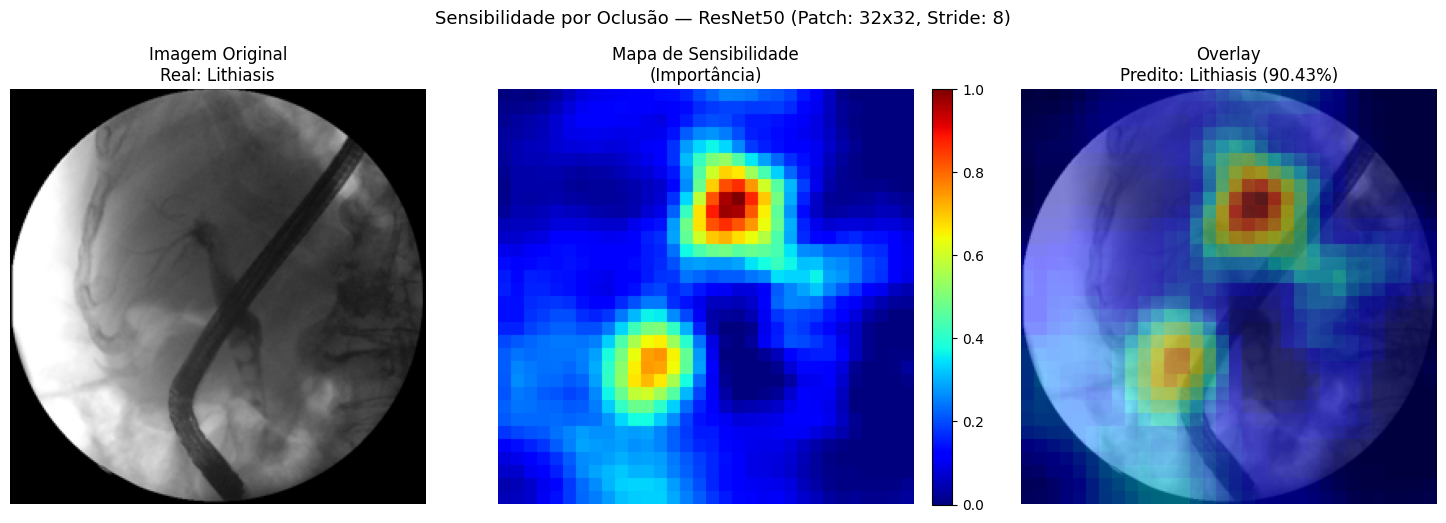

In [7]:
# Procurar arquivos .pth na pasta models/
available_models = [name for name, cfg in MODEL_REGISTRY.items() if cfg["path"].exists()]
print("Modelos encontrados em models/:", available_models)

if not available_models:
    print("AVISO: Nenhum checkpoint .pth foi encontrado no diretório models/.")
else:
    # Carregar o primeiro modelo disponível
    test_model_name = available_models[0]
    cfg = MODEL_REGISTRY[test_model_name]
    
    print(f"Carregando {test_model_name} de {cfg['path']}...")
    model = cfg["builder"](num_class)
    model.load_state_dict(torch.load(cfg["path"], map_location=device))
    model = model.to(device)
    
    # Escolher uma imagem aleatória do teste
    #random.seed(SEED)
    random_idx = random.randint(0, len(test_ds) - 1)
    img_path = test_images[random_idx]
    true_label = test_labels[random_idx]
    
    print(f"\nImagem de Teste selecionada (Índice {random_idx}):")
    print("Caminho:", img_path)
    print("Classe Real:", class_names[true_label])
    
    # Executar a oclusão com patch_size=32 e stride=8 para uma alta resolução visual
    heatmap, pred_class = plot_occlusion(
        model, test_model_name, img_path,
        target_class=true_label, patch_size=32, stride=8,
        img_size=cfg["input_size"]
    )


## 8. Análise Comparativa de Todos os Modelos

Agora vamos aplicar o algoritmo de oclusão na **mesma imagem médica** para **todos** os modelos que possuem pesos `.pth` válidos.
Desta forma, conseguimos realizar uma análise comparativa visual fantástica sobre a robustez e interpretabilidade de cada arquitetura.

Comparando modelos na mesma imagem: dataset_cleaned\test\Lithiasis\433_433_image4610.png
Classe Real: Lithiasis


A processar oclusão para: ResNet50 (Resolução: 256x256)


C:\Users\EVVLE\AppData\Local\Temp\ipykernel_27044\2934332016.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  m.load_state_dict(torch.load(cfg["path"], map_location=devi

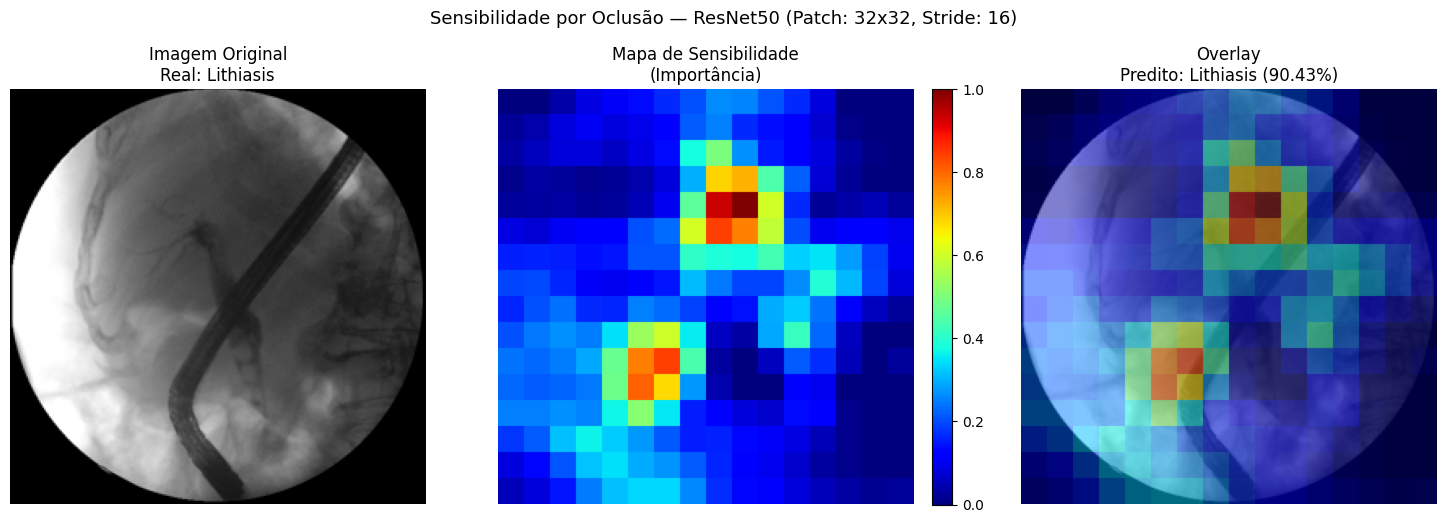


A processar oclusão para: DenseNet121 (Resolução: 256x256)


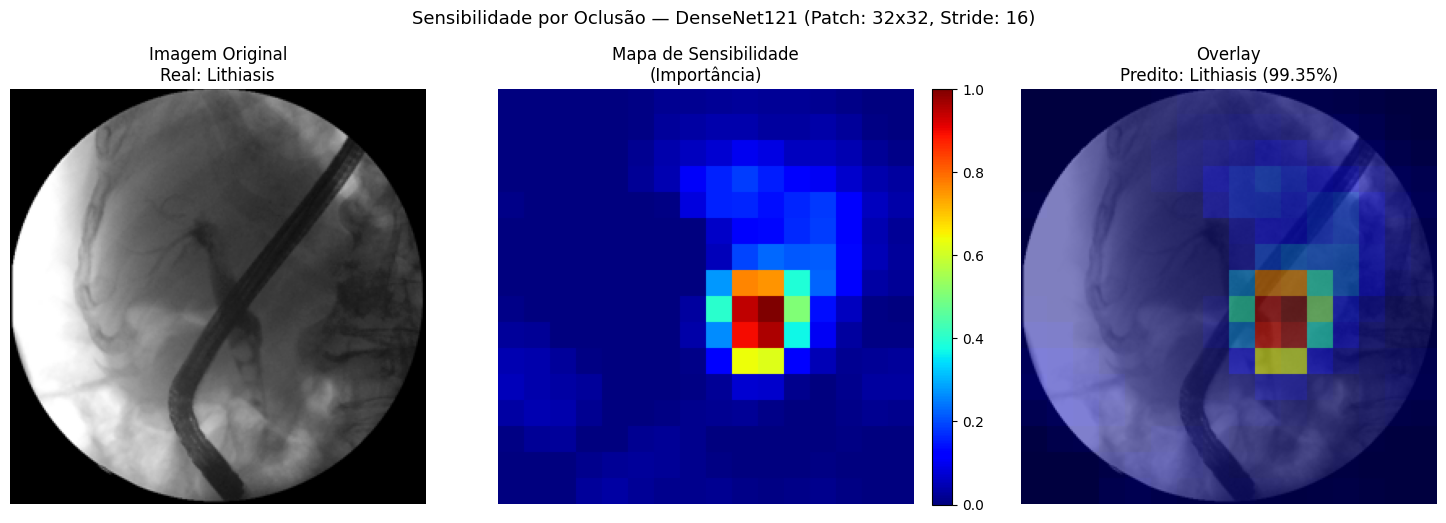


A processar oclusão para: MobileNetV2 (Resolução: 256x256)


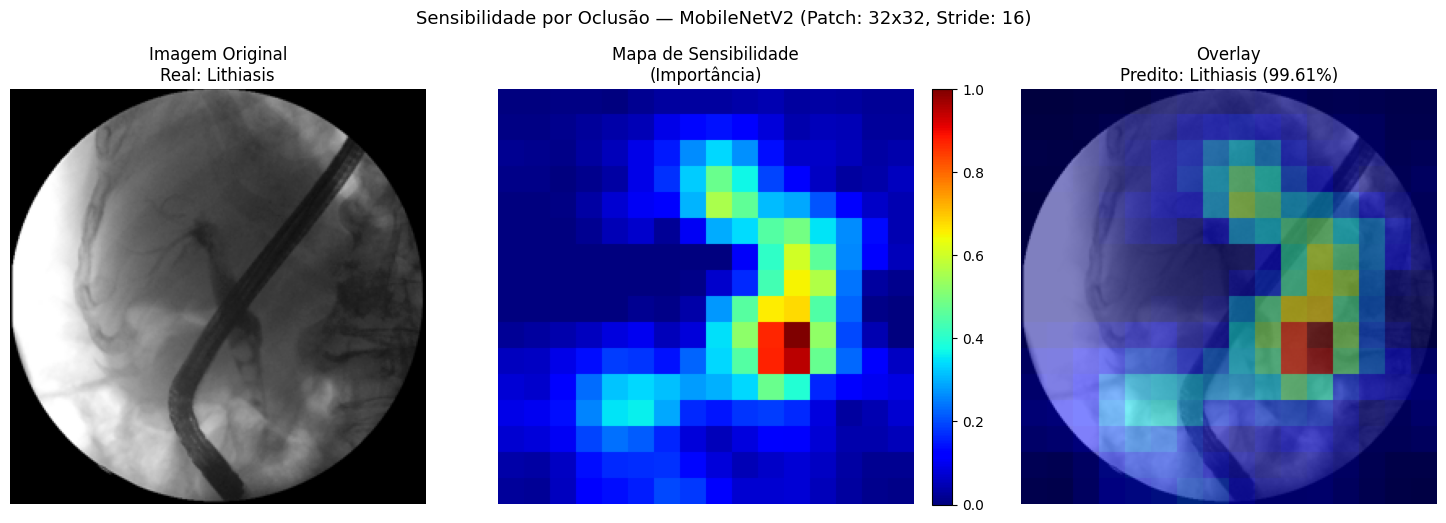


A processar oclusão para: EfficientNetB0 (Resolução: 256x256)


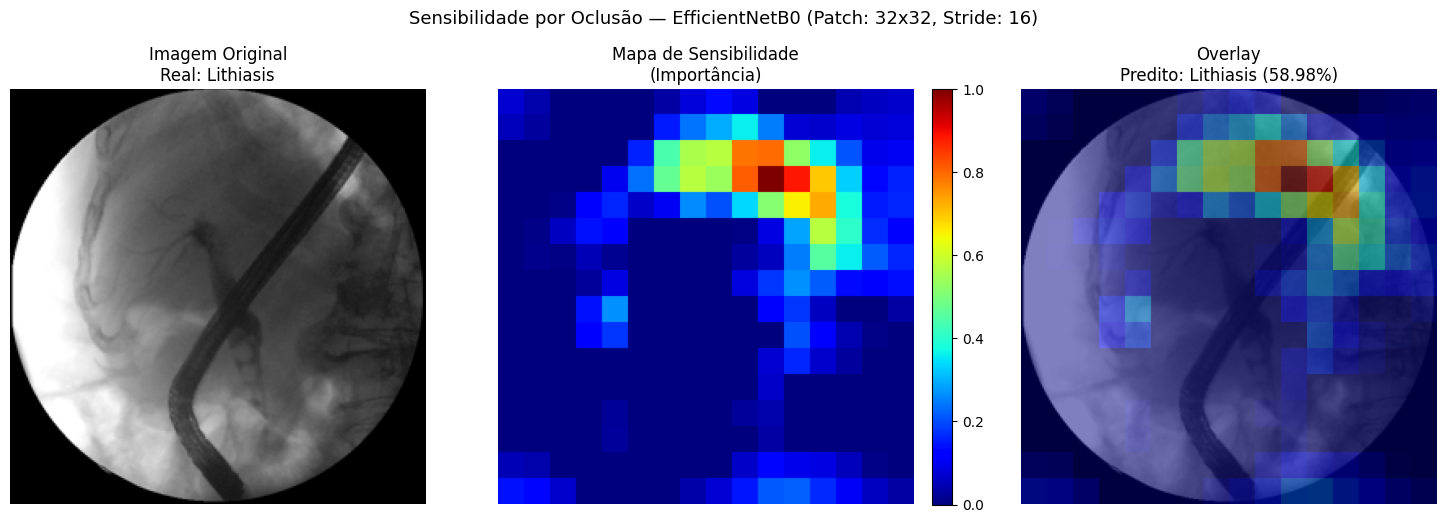


A processar oclusão para: EfficientNetB7 (Resolução: 256x256)


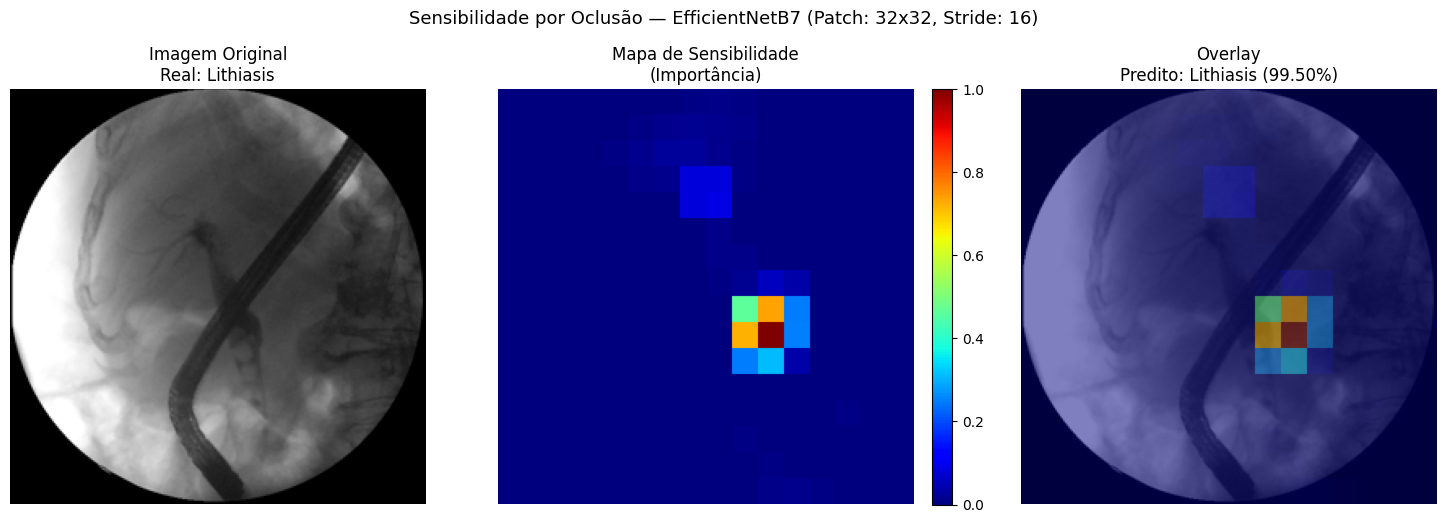


A processar oclusão para: DeiTIII (Resolução: 384x384)


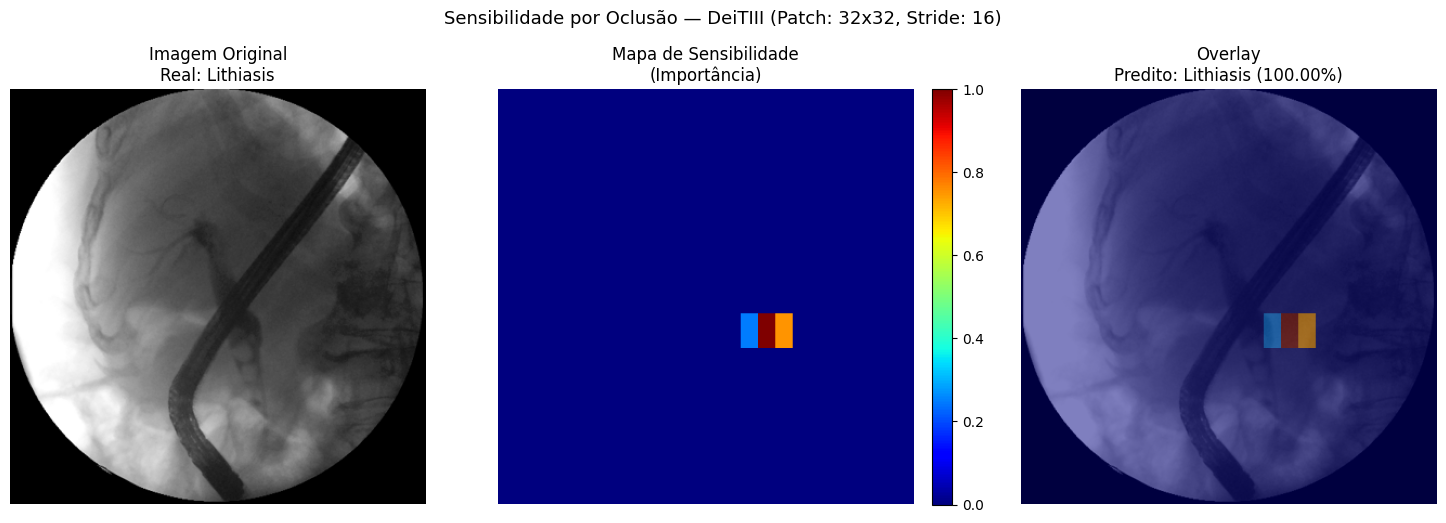

In [8]:
if not available_models:
    print("Nenhum modelo disponível para comparação.")
else:
    # Usamos a mesma imagem selecionada acima
    print(f"Comparando modelos na mesma imagem: {img_path}")
    print(f"Classe Real: {class_names[true_label]}\n")
    
    for model_name in available_models:
        cfg = MODEL_REGISTRY[model_name]
        
        print(f"\n==============================")
        print(f"A processar oclusão para: {model_name} (Resolução: {cfg['input_size']}x{cfg['input_size']})")
        
        # Carregar arquitetura e pesos
        m = cfg["builder"](num_class)
        m.load_state_dict(torch.load(cfg["path"], map_location=device))
        m = m.to(device)
        
        # Executar a oclusão com stride 16 (mais rápido para loop multimodelo)
        plot_occlusion(
            m, model_name, img_path,
            target_class=true_label, patch_size=32, stride=16,
            img_size=cfg["input_size"]
        )
        
        # Libertar memória
        del m
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
